In [ ]:
'''
WHAT ARE THE MOST DEMANDED SKILLS FOR THE TOP 3 MOST POPULAR DATA ROLES?

'''

In [1]:
# make sure python_course kernel is selected, restart if necessary

#importing libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Cleanup the dataset
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\stuco\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# lets filter the skills based on jobs in the US

df_US = df[df['job_country'] == 'United States']

In [6]:
df_job_skills = df_US.explode('job_skills')

df_job_skills[['job_skills', 'job_country']]

,job_skills,job_country
0,NaN,United States
3,python,United States
3,c++,United States
3,java,United States
3,matlab,United States
...,...,...
785692,r,United States
785703,NaN,United States
785705,sql,United States
785705,python,United States


In [18]:
df_skills_count = df_job_skills.groupby(['job_skills', 'job_title_short']).size()

# type(df_skills_count) --> lets transfrom this from a Series to a dataframe

df_skills_count = df_skills_count.reset_index(name='skill_count')

df_skills_count.sort_values(by="skill_count", ascending=False, inplace=True)

df_skills_count


,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
1785,vue.js,Business Analyst,1
60,arch,Business Analyst,1
71,asana,Machine Learning Engineer,1
968,no-sql,Machine Learning Engineer,1


In [24]:
# lets get all the unique job titles based off df_skills_count and make an array

job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3])

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

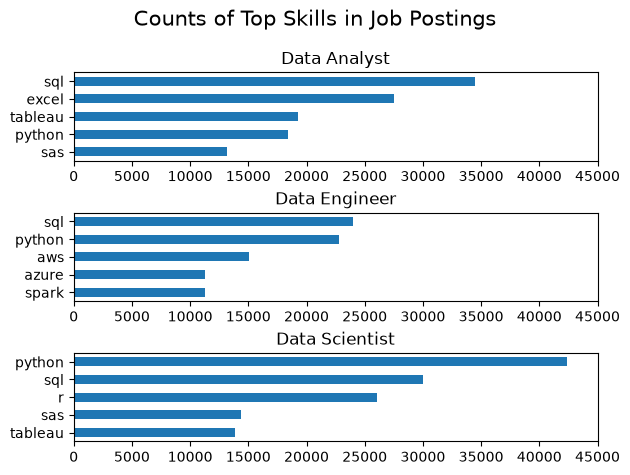

In [53]:
# now lets plot job_titles

fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title, legend=False)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0, 45000)

fig.suptitle('Counts of Top Skills in Job Postings', fontsize = 15)
fig.tight_layout(h_pad=0.5) # fixes overlap
plt.show()




In [56]:
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name='jobs_total')

df_job_title_count

,job_title_short,jobs_total
0,Data Analyst,67816
1,Data Scientist,58830
2,Data Engineer,35080
3,Senior Data Scientist,12946
4,Senior Data Analyst,11791
5,Senior Data Engineer,9289
6,Business Analyst,7382
7,Software Engineer,1814
8,Machine Learning Engineer,921
9,Cloud Engineer,423


In [ ]:
# we're going to merge the above DF with df_skills_count 

df_skills_percent = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')

# do some math to find skills percentage in jobs

df_skills_percent['skill_percent'] = 100 * (df_skills_percent['skill_count'] / df_skills_percent['jobs_total'])

df_skills_percent

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.013546
1866,arch,Business Analyst,1,7382,0.013546
1867,asana,Machine Learning Engineer,1,921,0.108578
1868,no-sql,Machine Learning Engineer,1,921,0.108578


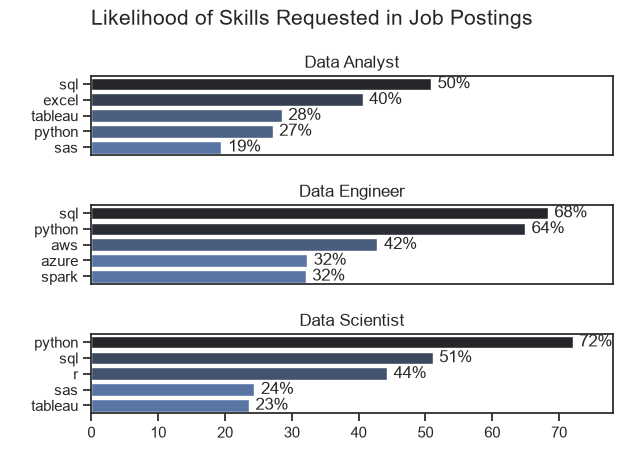

In [ ]:
# now we'll plot the percents

fig, ax = plt.subplots(len(job_titles), 1) # subplots use fig and ax, not plt

sns.set_theme(style='ticks')

# when we use subplots, we have to make a for loop. 
for i, job_title in enumerate(job_titles):
    df_plot = df_skills_percent[df_skills_percent['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel(' ')
    ax[i].set_xlabel(' ')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)
    
    # we can make a nested for loop to show percentages for each datapoint inside the for loop

    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f"{int(v):.0f}%", va='center')

    if i != len(job_titles) - 1: 
        ax[i].set_xticks([]) # this takes away the x labels but the for loop keeps the bottom one included

fig.suptitle('Likelihood of Skills Requested in Job Postings', fontsize = 15)
fig.tight_layout(h_pad=0.5) # fixes overlap
plt.show()

# note, Seaborn doesn't use invert_yaxis, can leave it alone
 